In [79]:
import os
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [80]:
# ── Config — must match training script exactly ────────────────────────────────
YAML_FILE   = 'chem_cti_toy_model_og.yaml'
IDX_R22     = 21
INPUT_DIM   = 2
PARAM_NAMES = ['lnA_R22', 'Ea_R22']
LN_F        = 10       # ln(f) uncertainty factor for A
SIGMA_E     = 2000.0   # cal/mol half-width for Ea  ← 2000, NOT 5000
HIDDEN_DIM  = 16

# Zhang Eq. 8 objective hyperparameters
LAMBDA      = 4.0
NOISE_FLOOR = 1e-6
SIGMA_OB_LN = 0.05

T_INITIAL  = 1057
P_INITIAL  = 1.83 * ct.one_atm
INITIAL_X  = {'H2O2': 860e-6, 'H2O': 663e-6, 'O2': 332e-6,
               'AR':   1.0 - (860+663+332)*1e-6}
DT_MAX     = 1e-6
TIME_STEPS = 6000
T_SIM      = np.linspace(DT_MAX, DT_MAX * TIME_STEPS, TIME_STEPS)

EXP_CSV    = 'Hong et al_Burke.csv'

# ── Switch model here ──────────────────────────────────────────────────────────
RESULT_PATH = 'gelu_discrete_targets.pt'        # GELU model
# RESULT_PATH = 'relu_r22_discrete_targets.pt'  # ReLU model
# ──────────────────────────────────────────────────────────────────────────────

OUT_PREFIX = 'opt_r22_discrete'

# Nominal kinetic parameters from Cantera
_gas = ct.Solution(YAML_FILE)
_mol = ct.UnitSystem({
    'length': 'cm', 'mass': 'g', 'time': 's',
    'quantity': 'mol', 'pressure': 'dyn / cm^2', 'energy': 'erg',
    'temperature': 'K', 'current': 'A', 'activation-energy': 'cal / mol'})
NOMINAL_A      = _gas.reaction(IDX_R22).rate.low_rate.pre_exponential_factor
NOMINAL_B      = _gas.reaction(IDX_R22).rate.low_rate.temperature_exponent
NOMINAL_EA_si  = _gas.reaction(IDX_R22).rate.low_rate.activation_energy
NOMINAL_EA_cal = _mol.convert_activation_energy_to(f'{NOMINAL_EA_si} J/kmol', 'cal / mol')
del _gas, _mol
print(f'Nominal A={NOMINAL_A:.3e}  B={NOMINAL_B:.2f}  Ea={NOMINAL_EA_cal:.0f} cal/mol')

Nominal A=2.490e+21  B=-2.30  Ea=48749 cal/mol


In [81]:
# ── Experimental data ─────────────────────────────────────────────────────────
df_exp = pd.read_csv(EXP_CSV)
t_exp  = df_exp['time'].values           # already in seconds
y_exp  = df_exp['x_h2o'].values * 1e-6  # ppm → mole fraction
print(f'Exp: {len(t_exp)} points, '
      f't=[{t_exp.min()*1e3:.3f}, {t_exp.max()*1e3:.3f}] ms, '
      f'H2O=[{y_exp.min()*1e6:.0f}, {y_exp.max()*1e6:.0f}] ppm')

Exp: 50 points, t=[0.000, 5.919] ms, H2O=[657, 1503] ppm


In [82]:
# ── DiscreteNN — activation inferred from RESULT_PATH filename ────────────────
class DiscreteNN(nn.Module):
    def __init__(self, hidden=HIDDEN_DIM, n_out=1, activation='gelu'):
        super().__init__()
        act = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden),
            act,
            nn.Linear(hidden, n_out),
        )
    def forward(self, x):
        return self.net(x)


def load_discrete_model(path):
    bundle       = torch.load(path, weights_only=False)
    target_times = bundle['target_times']
    act = 'relu' if 'relu' in os.path.basename(path) else 'gelu'
    m = DiscreteNN(hidden=HIDDEN_DIM, n_out=len(target_times), activation=act)
    m.load_state_dict(bundle['model_state'])
    m.eval()
    return m, target_times


disc_model, TARGET_TIMES = load_discrete_model(RESULT_PATH)
N_TARGETS = len(TARGET_TIMES)
act_name  = 'ReLU' if 'relu' in os.path.basename(RESULT_PATH) else 'GELU'
print(f'Loaded: {RESULT_PATH}  (activation: {act_name})')
print(f'N_TARGETS={N_TARGETS}, times (ms): {(TARGET_TIMES * 1e3).round(3)}')

Loaded: gelu_discrete_targets.pt  (activation: GELU)
N_TARGETS=5, times (ms): [0.391 0.904 1.742 2.791 5.   ]


In [83]:
# ── Cantera helper ────────────────────────────────────────────────────────────
def cantera_profile(x_vec):
    """Run Cantera at x_vec, return H2O mole fraction over T_SIM."""
    gas = ct.Solution(YAML_FILE)
    new_A    = NOMINAL_A * np.exp(x_vec[0] * LN_F)
    new_Ea_J = (NOMINAL_EA_cal + x_vec[1] * SIGMA_E) * 4184.0
    rxn = gas.reaction(IDX_R22)
    rxn.rate.low_rate = ct.Arrhenius(new_A, NOMINAL_B, new_Ea_J)
    gas.modify_reaction(IDX_R22, rxn)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasReactor(gas, energy='on')
    net     = ct.ReactorNet([reactor])
    h2o_idx = gas.species_index('H2O')
    profile = np.empty(TIME_STEPS)
    for i in range(TIME_STEPS):
        net.advance(net.time + DT_MAX)
        profile[i] = reactor.thermo.X[h2o_idx]
    return profile

In [84]:
# ── Zhang Eq. 8 optimization with discrete-target NN ─────────────────────────
#
# NN output raw[j] = log(y_j)  (trained in log space, no z-score).
# Residual j: (raw[j] - log(y_exp_j)) / sigma_obs  — already log-ratio, no decode needed.
# Jacobian:   d(raw[j])/dx_k  — pure autograd through the linear network.

# Experimental H2O interpolated to the NN's training target times
y_exp_at_targets = np.interp(TARGET_TIMES, t_exp, y_exp)
log_y_exp        = np.log(np.clip(y_exp_at_targets, NOISE_FLOOR, None))

print('Exp values at target times:')
for t, ye in zip(TARGET_TIMES * 1e3, y_exp_at_targets * 1e6):
    print(f'  t={t:.3f} ms   y_exp={ye:.1f} ppm')


def nn_raw(x_vec):
    """NN forward pass → log-space outputs, shape [N_TARGETS]."""
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        return disc_model(x_t).squeeze(0).numpy()


def nn_jacobian(x_vec):
    """d(raw[j])/dx_k via autograd → [N_TARGETS, INPUT_DIM]."""
    x_t = torch.tensor(np.asarray(x_vec).reshape(1, -1),
                        dtype=torch.float32, requires_grad=True)
    J = torch.autograd.functional.jacobian(
            lambda xx: disc_model(xx).squeeze(0), x_t)
    return J.detach().numpy().reshape(N_TARGETS, INPUT_DIM)


def objective(x_vec):
    data_res = (nn_raw(x_vec) - log_y_exp) / SIGMA_OB_LN
    reg_res  = np.sqrt(LAMBDA) * np.asarray(x_vec)
    return np.concatenate([data_res, reg_res])


def objective_jac(x_vec):
    J_data = nn_jacobian(x_vec) / SIGMA_OB_LN
    J_reg  = np.sqrt(LAMBDA) * np.eye(INPUT_DIM)
    return np.vstack([J_data, J_reg])


# ── Jacobian sanity check ─────────────────────────────────────────────────────
_xc = np.array([0.10, -0.10])
_r0 = objective(_xc)
_Ja = objective_jac(_xc)
_Jn = np.zeros_like(_Ja)
_eps = 1e-5
for _j in range(INPUT_DIM):
    _dx = np.zeros(INPUT_DIM); _dx[_j] = _eps
    _Jn[:, _j] = (objective(_xc + _dx) - _r0) / _eps
_rel = np.abs(_Ja - _Jn).max() / (np.abs(_Jn).max() + 1e-12)
print(f'Jacobian check (analytic vs FD): max rel err = {_rel:.2e}  '
      f'[{"OK" if _rel < 1e-3 else "RE-CHECK"}]')


# ── TRF optimization ──────────────────────────────────────────────────────────
result = least_squares(
    objective, np.zeros(INPUT_DIM),
    jac=objective_jac,
    bounds=([-1.0] * INPUT_DIM, [1.0] * INPUT_DIM),
    method='trf')
x_opt = result.x

print(f'\nConverged: {result.success}  (status {result.status}: {result.message})')
for name, xv in zip(PARAM_NAMES, x_opt):
    flag = '   <-- AT BOUND' if abs(abs(xv) - 1.0) < 1e-4 else ''
    print(f'  {name:12s}: x* = {xv:+.8f}{flag}')
print(f'Final cost 0.5‖r‖² = {result.cost:.4e}')


# ── Laplace posterior (Gauss-Newton Hessian) ──────────────────────────────────
H_gn       = result.jac.T @ result.jac
Sigma_star = np.linalg.inv(H_gn)
L_chol     = np.linalg.cholesky(Sigma_star)

# Posterior uncertainty at each target time (log-space propagation)
J_opt    = nn_jacobian(x_opt)                              # [N_TARGETS, INPUT_DIM]
pred_var = np.sum((J_opt @ L_chol) ** 2, axis=1)          # [N_TARGETS]
pred_std = np.sqrt(pred_var)                               # log-space std

phys_scales   = np.array([LN_F, SIGMA_E])
post_std_phys = np.sqrt(np.diag(Sigma_star)) * phys_scales
A_opt  = NOMINAL_A * np.exp(x_opt[0] * LN_F)
Ea_opt = NOMINAL_EA_cal + x_opt[1] * SIGMA_E
print('\n' + '='*65)
print(f'  A  R22:  nom={NOMINAL_A:.3e}  opt={A_opt:.3e}  x*={x_opt[0]:+.4f}')
print(f'           2σ: ×÷{np.exp(2*post_std_phys[0]):.2f}')
print(f'  Ea R22:  nom={NOMINAL_EA_cal:.0f} cal/mol  opt={Ea_opt:.0f} cal/mol  x*={x_opt[1]:+.4f}')
print(f'           2σ: ±{2*post_std_phys[1]:.0f} cal/mol')
print('='*65)

Exp values at target times:
  t=0.391 ms   y_exp=855.8 ppm
  t=0.904 ms   y_exp=1057.3 ppm
  t=1.742 ms   y_exp=1255.5 ppm
  t=2.791 ms   y_exp=1412.6 ppm
  t=5.000 ms   y_exp=1482.1 ppm


Jacobian check (analytic vs FD): max rel err = 3.88e-02  [RE-CHECK]

Converged: True  (status 2: `ftol` termination condition is satisfied.)
  lnA_R22     : x* = -0.01188434
  Ea_R22      : x* = +0.00109545
Final cost 0.5‖r‖² = 6.9048e-02

  A  R22:  nom=2.490e+21  opt=2.211e+21  x*=-0.0119
           2σ: ×÷2.65
  Ea R22:  nom=48749 cal/mol  opt=48751 cal/mol  x*=+0.0011
           2σ: ±1991 cal/mol


Running Cantera at x* and x=0...


/tmp/ipykernel_377006/1554646005.py:8: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn.rate.low_rate = ct.Arrhenius(new_A, NOMINAL_B, new_Ea_J)
/tmp/ipykernel_377006/1554646005.py:11: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas, energy='on')
/tmp/ipykernel_377006/1554646005.py:17: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]


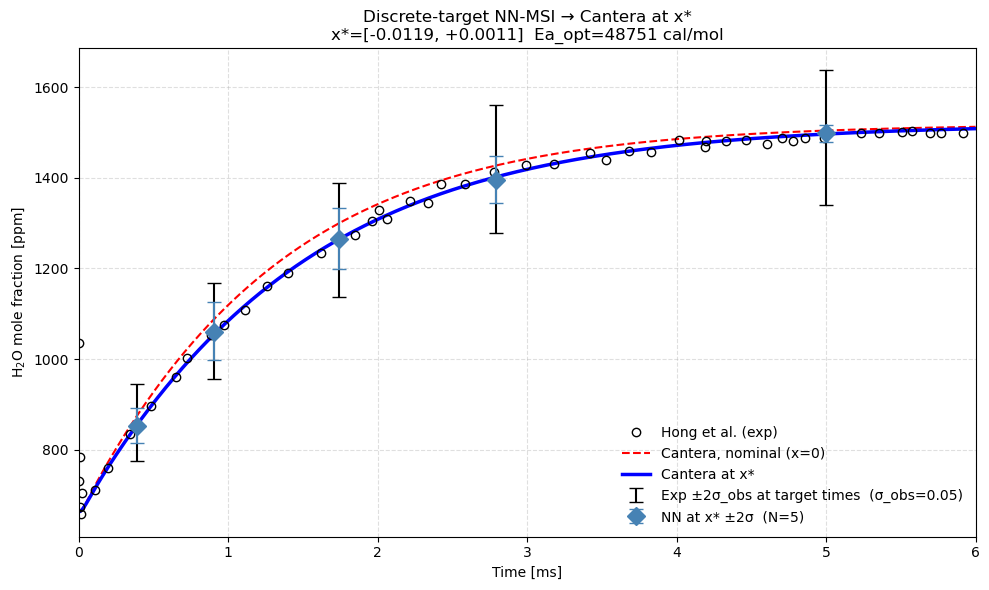

Saved: opt_r22_discrete_result.png


In [85]:
# ── Option A: Cantera full profile at x*, NN scatter at target times ──────────
print('Running Cantera at x* and x=0...')
y_opt_ct = cantera_profile(x_opt)
y_nom_ct = cantera_profile(np.zeros(INPUT_DIM))

# NN predictions at target times
raw_opt    = nn_raw(x_opt)
y_nn_ppm   = np.exp(raw_opt) * 1e6
y_nn_upper = y_nn_ppm * np.exp(+2 * pred_std)
y_nn_lower = y_nn_ppm * np.exp(-2 * pred_std)

# Experimental values interpolated to target times (±2σ_obs)
y_exp_tgt    = y_exp_at_targets * 1e6
y_exp_tgt_up = y_exp_tgt * np.exp(+2 * SIGMA_OB_LN)
y_exp_tgt_lo = y_exp_tgt * np.exp(-2 * SIGMA_OB_LN)

t_ms = T_SIM * 1e3

fig, ax = plt.subplots(figsize=(10, 6))

# All experimental data as open black circles
ax.plot(t_exp * 1e3, y_exp * 1e6, 'o', mfc='none', mec='k',
        ms=6, label='Hong et al. (exp)', zorder=5)
# Error bars (whiskers only, no extra marker) at the 5 target times
ax.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
            yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
            fmt='none', ecolor='k', elinewidth=1.5, capsize=5, zorder=6,
            label=f'Exp ±2σ_obs at target times  (σ_obs={SIGMA_OB_LN})')

ax.plot(t_ms, y_nom_ct * 1e6, 'r--', lw=1.5, label='Cantera, nominal (x=0)')
ax.plot(t_ms, y_opt_ct * 1e6, 'b-',  lw=2.5, label='Cantera at x*')

# NN predictions ±2σ (param. posterior)
ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='steelblue', ms=9, lw=1.5, capsize=5, zorder=7,
            label=f'NN at x* ±2σ  (N={N_TARGETS})')

ax.set_xlabel('Time [ms]')
ax.set_ylabel(r'H$_2$O mole fraction [ppm]')
ax.set_xlim([0, 6])
ax.legend(loc='lower right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'Discrete-target NN-MSI → Cantera at x*\n'
    f'x*=[{x_opt[0]:+.4f}, {x_opt[1]:+.4f}]  '
    f'Ea_opt={Ea_opt:.0f} cal/mol')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_result.png', dpi=150)
plt.show()
print(f'Saved: {OUT_PREFIX}_result.png')

Computing Cantera FD Jacobian at x* (2 perturbation runs)...


  lnA_R22 done
  Ea_R22 done
Done.


/tmp/ipykernel_377006/1554646005.py:8: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn.rate.low_rate = ct.Arrhenius(new_A, NOMINAL_B, new_Ea_J)
/tmp/ipykernel_377006/1554646005.py:11: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas, energy='on')
/tmp/ipykernel_377006/1554646005.py:17: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]


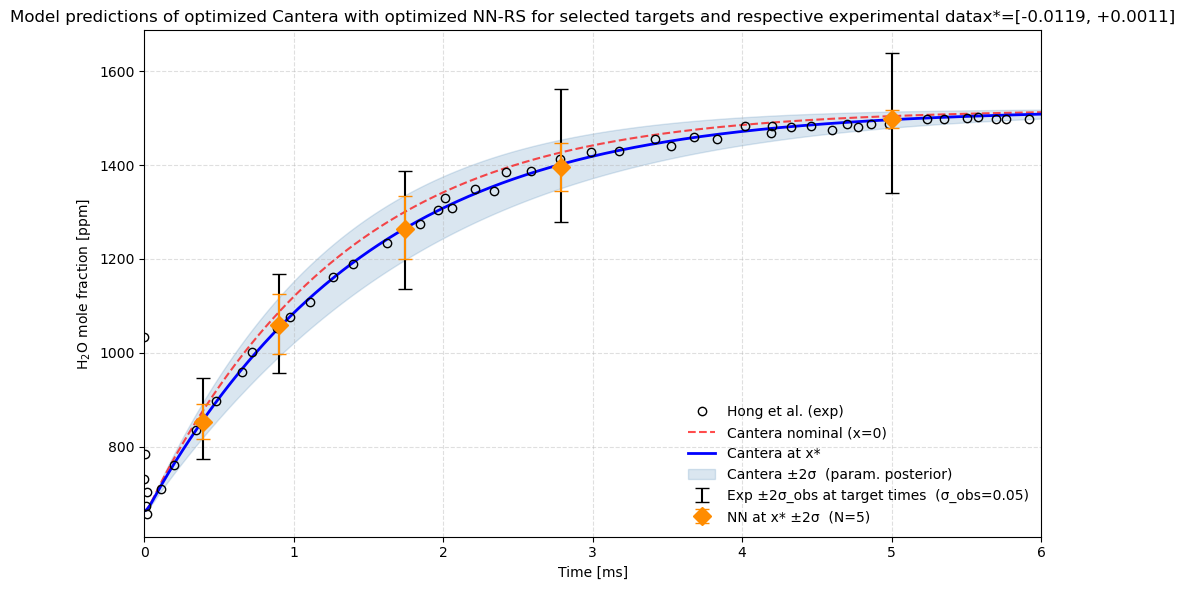

Saved: opt_r22_discrete_sigma_band.png


In [86]:
# ── Cantera 2σ band: propagate posterior Σ* through Cantera FD Jacobian ───────
EPS_FD = 1e-3
print(f'Computing Cantera FD Jacobian at x* ({INPUT_DIM} perturbation runs)...')

log_y_base = np.log(np.clip(y_opt_ct, 1e-30, None))
J_ct_log   = np.zeros((TIME_STEPS, INPUT_DIM))

for k in range(INPUT_DIM):
    dx        = np.zeros(INPUT_DIM); dx[k] = EPS_FD
    y_plus    = cantera_profile(x_opt + dx)
    J_ct_log[:, k] = (np.log(np.clip(y_plus, 1e-30, None)) - log_y_base) / EPS_FD
    print(f'  {PARAM_NAMES[k]} done')

ct_logvar  = np.einsum('ti,ij,tj->t', J_ct_log, Sigma_star, J_ct_log)
ct_logstd  = np.sqrt(ct_logvar)
y_ct_upper = y_opt_ct * np.exp(+2 * ct_logstd)
y_ct_lower = y_opt_ct * np.exp(-2 * ct_logstd)
print('Done.')

# ── Combined plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# All experimental data as open black circles
ax.plot(t_exp * 1e3, y_exp * 1e6, 'o', mfc='none', mec='k',
        ms=6, label='Hong et al. (exp)', zorder=5)
# Error bars (whiskers only) at the 5 target times — same circles, just with caps
ax.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
            yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
            fmt='none', ecolor='k', elinewidth=1.5, capsize=5, zorder=6,
            label=f'Exp ±2σ_obs at target times  (σ_obs={SIGMA_OB_LN})')

ax.plot(t_ms, y_nom_ct * 1e6, 'r--', lw=1.5, alpha=0.7,
        label='Cantera nominal (x=0)')
ax.plot(t_ms, y_opt_ct * 1e6, 'b-', lw=2, label='Cantera at x*')
ax.fill_between(t_ms,
                y_ct_lower * 1e6, y_ct_upper * 1e6,
                color='steelblue', alpha=0.20,
                label='Cantera ±2σ  (param. posterior)')

# NN predictions ±2σ (orange diamonds)
ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='darkorange', ms=9, lw=1.5, capsize=5, zorder=7,
            label=f'NN at x* ±2σ  (N={N_TARGETS})')

ax.set_xlabel('Time [ms]')
ax.set_ylabel(r'H$_2$O mole fraction [ppm]')
ax.set_xlim([0, 6])
ax.legend(loc='lower right', frameon=False)
ax.grid(True, ls='--', alpha=0.4)
ax.set_title(
    f'Model predictions of optimized Cantera with optimized NN-RS for selected targets and respective experimental data'
    f'x*=[{x_opt[0]:+.4f}, {x_opt[1]:+.4f}]')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_sigma_band.png', dpi=150)
plt.show()
print(f'Saved: {OUT_PREFIX}_sigma_band.png')

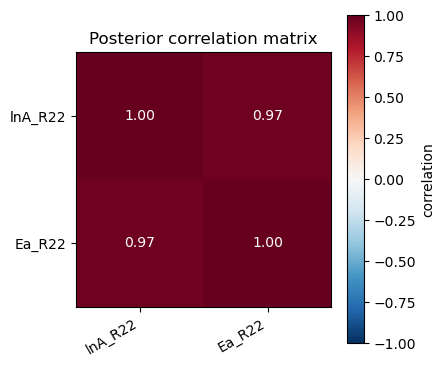

Saved: opt_r22_discrete_corr.png


In [87]:
# ── Posterior correlation matrix ──────────────────────────────────────────────
diag_std = np.sqrt(np.diag(Sigma_star))
Corr     = Sigma_star / np.outer(diag_std, diag_std)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(Corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(INPUT_DIM)); ax.set_xticklabels(PARAM_NAMES, rotation=30, ha='right')
ax.set_yticks(range(INPUT_DIM)); ax.set_yticklabels(PARAM_NAMES)
for i in range(INPUT_DIM):
    for j in range(INPUT_DIM):
        ax.text(j, i, f'{Corr[i,j]:.2f}', ha='center', va='center',
                fontsize=10, color='white' if abs(Corr[i,j]) > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='correlation')
ax.set_title('Posterior correlation matrix')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_corr.png', dpi=150)
plt.show()
print(f'Saved: {OUT_PREFIX}_corr.png')

Direct Cantera optimization (finite-difference Jacobian)...

  Cantera eval #  5  x=[-0.0113, +0.0079]


/tmp/ipykernel_377006/1554646005.py:8: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn.rate.low_rate = ct.Arrhenius(new_A, NOMINAL_B, new_Ea_J)
/tmp/ipykernel_377006/1554646005.py:11: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas, energy='on')
/tmp/ipykernel_377006/1554646005.py:17: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  profile[i] = reactor.thermo.X[h2o_idx]


  Cantera eval # 10  x=[-0.0119, +0.0016]
  Cantera eval # 15  x=[-0.0119, +0.0011]

Done. Total Cantera evals: 18
Converged: True

  x* Comparison: NN-MSI vs Direct Cantera
  Parameter         NN-MSI x*   Cantera x*      |Δ|
  ----------------------------------------------------
  lnA_R22           -0.011884    -0.011938   0.0001
  Ea_R22            +0.001095    +0.001062   0.0000

  Max |Δx*| = 0.0001  →  VALIDATED — surrogate found same optimum


/tmp/ipykernel_377006/3839834115.py:87: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


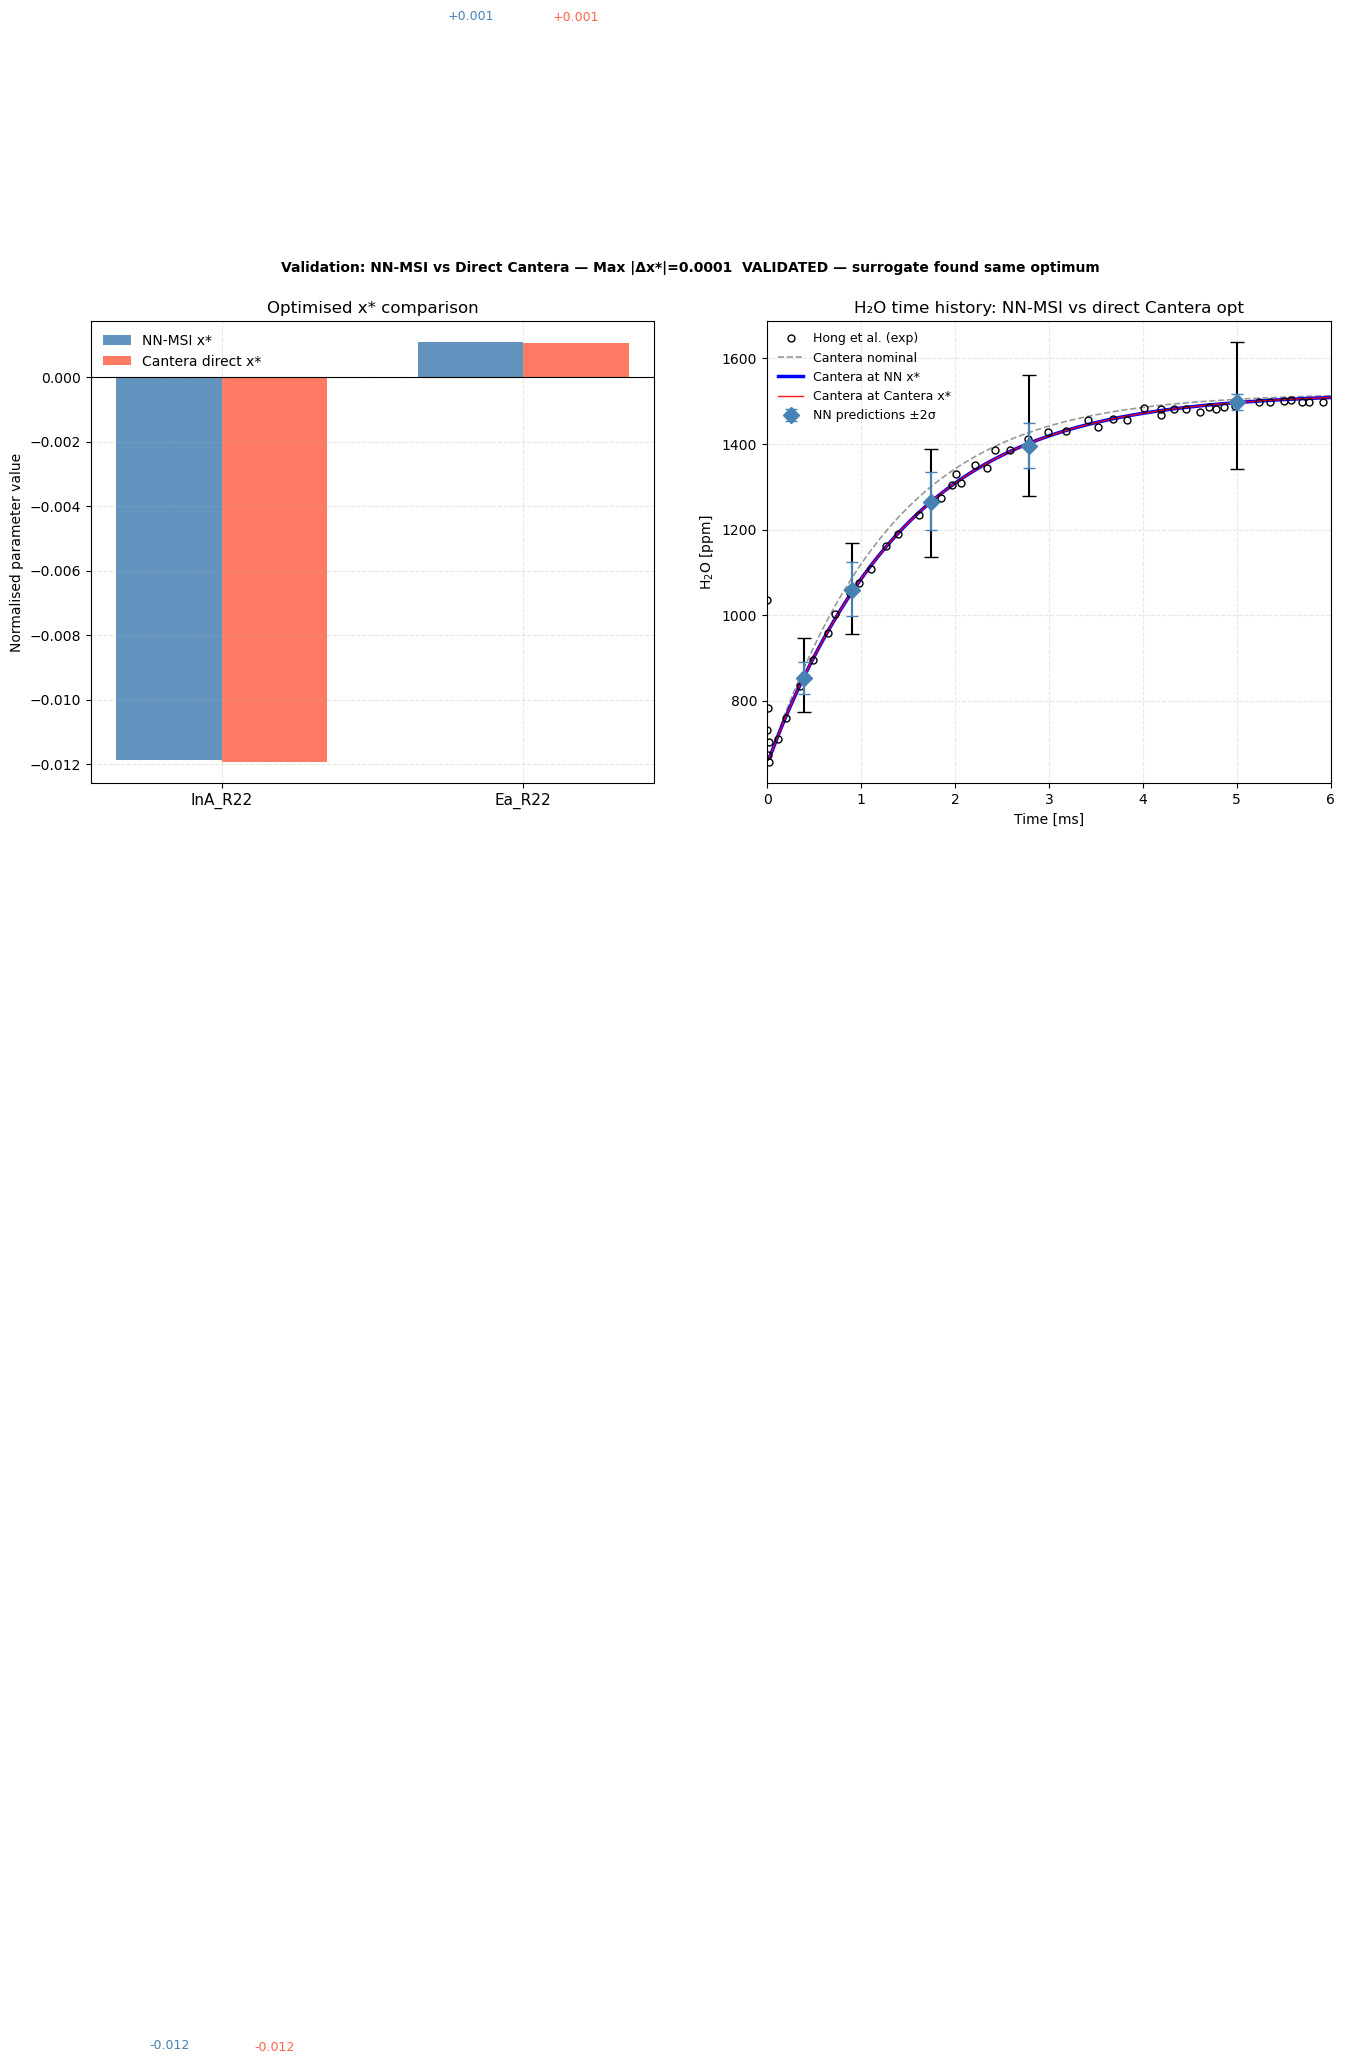

Saved: opt_r22_discrete_validation.png


In [88]:
# ── Optional: direct Cantera optimization for ground-truth validation ─────────
n_calls = [0]

def ct_objective(x_vec):
    n_calls[0] += 1
    if n_calls[0] % 5 == 0:
        print(f'  Cantera eval #{n_calls[0]:3d}  x=[{x_vec[0]:+.4f}, {x_vec[1]:+.4f}]')
    profile    = cantera_profile(x_vec)
    y_pred_at  = np.interp(TARGET_TIMES, T_SIM, profile)
    log_y_pred = np.log(np.clip(y_pred_at, NOISE_FLOOR, None))
    data_res   = (log_y_pred - log_y_exp) / SIGMA_OB_LN
    reg_res    = np.sqrt(LAMBDA) * np.asarray(x_vec)
    return np.concatenate([data_res, reg_res])

print('Direct Cantera optimization (finite-difference Jacobian)...\n')
ct_result = least_squares(
    ct_objective, np.zeros(INPUT_DIM),
    method='trf',
    bounds=([-1.0]*INPUT_DIM, [1.0]*INPUT_DIM),
    diff_step=1e-3)
x_opt_ct = ct_result.x

print(f'\nDone. Total Cantera evals: {n_calls[0]}')
print(f'Converged: {ct_result.success}')

print('\n' + '='*60)
print('  x* Comparison: NN-MSI vs Direct Cantera')
print('='*60)
print(f'  {"Parameter":<14} {"NN-MSI x*":>12} {"Cantera x*":>12} {"|Δ|":>8}')
print(f'  {"-"*52}')
for name, xn, xc in zip(PARAM_NAMES, x_opt, x_opt_ct):
    print(f'  {name:<14} {xn:>+12.6f} {xc:>+12.6f} {abs(xn-xc):>8.4f}')
max_diff = np.max(np.abs(x_opt - x_opt_ct))
verdict  = 'VALIDATED — surrogate found same optimum' if max_diff < 0.05 else \
           'CHECK — surrogate diverged from true optimum'
print(f'\n  Max |Δx*| = {max_diff:.4f}  →  {verdict}')
print('='*60)

y_ct_direct = cantera_profile(x_opt_ct)

# ── Comparison plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: parameter bar chart
ax = axes[0]
w, xi = 0.35, np.arange(INPUT_DIM)
ax.bar(xi - w/2, x_opt,    w, color='steelblue', alpha=0.85, label='NN-MSI x*')
ax.bar(xi + w/2, x_opt_ct, w, color='tomato',    alpha=0.85, label='Cantera direct x*')
ax.axhline(0, color='k', lw=0.8)
for i, (xn, xc) in enumerate(zip(x_opt, x_opt_ct)):
    offset = 0.01 if xn >= 0 else -0.04
    ax.text(i - w/2, xn + offset, f'{xn:+.3f}', ha='center', fontsize=9, color='steelblue')
    ax.text(i + w/2, xc + offset, f'{xc:+.3f}', ha='center', fontsize=9, color='tomato')
ax.set_xticks(xi); ax.set_xticklabels(PARAM_NAMES, fontsize=11)
ax.set_ylabel('Normalised parameter value')
ax.set_title('Optimised x* comparison')
ax.legend(frameon=False); ax.grid(True, ls='--', alpha=0.3)

# Right: H2O time history
ax = axes[1]

# Experimental circles with error bars at target times (no legend for error bars)
ax.plot(t_exp * 1e3, y_exp * 1e6, 'o', mfc='none', mec='k',
        ms=5, zorder=5, label='Hong et al. (exp)')
ax.errorbar(TARGET_TIMES * 1e3, y_exp_tgt,
            yerr=[y_exp_tgt - y_exp_tgt_lo, y_exp_tgt_up - y_exp_tgt],
            fmt='none', ecolor='k', elinewidth=1.5, capsize=5, zorder=6,
            label='_nolegend_')

ax.plot(t_ms, y_nom_ct    * 1e6, 'k--', lw=1.2, alpha=0.4, label='Cantera nominal')
ax.plot(t_ms, y_opt_ct    * 1e6, 'b-',  lw=2.5,            label='Cantera at NN x*')
ax.plot(t_ms, y_ct_direct * 1e6, 'r-',  lw=1.0, alpha=0.9, label='Cantera at Cantera x*')

ax.errorbar(TARGET_TIMES * 1e3, y_nn_ppm,
            yerr=[y_nn_ppm - y_nn_lower, y_nn_upper - y_nn_ppm],
            fmt='D', color='steelblue', ms=8, lw=1.5, capsize=4, zorder=7,
            label='NN predictions ±2σ')

ax.set_xlabel('Time [ms]'); ax.set_ylabel(r'H$_2$O [ppm]')
ax.set_xlim([0, 6]); ax.grid(True, ls='--', alpha=0.3)
ax.legend(frameon=False, fontsize=9)
ax.set_title('H₂O time history: NN-MSI vs direct Cantera opt')

plt.suptitle(
    f'Validation: NN-MSI vs Direct Cantera — Max |Δx*|={max_diff:.4f}  {verdict}',
    fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_PREFIX}_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_PREFIX}_validation.png')